# Shared front-end performance across all folds

This notebook summarizes the fold-specific shared front-end training performed by `02_frontend_pretrain.ipynb`. It reads the five `shared_frontend_history.csv` files, compares optimization behavior, and reports the best validation checkpoint for each fold.

The best epoch is defined as the epoch with the highest `validation_macro_dice`, matching the reconstruction target of four binary channels in `[femur, tibia, patella, fibula]` order. No training artifacts are modified.

## Success criteria

1. Exactly folds 0–4 are loaded and their schemas are validated.
2. Training/validation loss and macro-Dice trajectories are shown for every fold.
3. Best-epoch macro-Dice and per-bone Dice are summarized across folds.
4. Fold-level best-epoch statistics and across-fold mean ± standard deviation are displayed.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

STAGE2_SCHEMA = "foundation_stage2_v1"
EXPECTED_FOLDS = list(range(5))
BONES = ["femur", "tibia", "patella", "fibula"]
FOLD_COLORS = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#D55E00"]

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Load and validate all fold histories

The project root is discovered from the notebook's current working directory. Both `fold0` and `fold_0` directory spellings are accepted because historical handoffs use both forms.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "configs" / "baseline_protocol_v1.json").is_file():
            return candidate
    raise FileNotFoundError("Project root containing configs/baseline_protocol_v1.json was not found")


ROOT = find_project_root(Path.cwd())
MODEL_ROOT = ROOT / "models" / STAGE2_SCHEMA
HISTORY_PATHS = sorted(MODEL_ROOT.glob("fold*/shared_frontend_history.csv"))

required_columns = {
    "epoch", "train_loss", "validation_loss",
    "train_macro_dice", "validation_macro_dice",
    *(f"validation_dice_{bone}" for bone in BONES),
    "lr", "elapsed_seconds",
}

frames = []
seen_folds = set()
for path in HISTORY_PATHS:
    match = re.fullmatch(r"fold_?(\d+)", path.parent.name)
    if match is None:
        continue
    fold = int(match.group(1))
    if fold in seen_folds:
        raise ValueError(f"Duplicate history detected for fold {fold}")
    history = pd.read_csv(path)
    missing = required_columns.difference(history.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    if history.empty or history[list(required_columns)].isna().any().any():
        raise ValueError(f"{path} is empty or contains missing metric values")
    history = history.copy()
    history["fold"] = fold
    frames.append(history)
    seen_folds.add(fold)

if sorted(seen_folds) != EXPECTED_FOLDS:
    raise FileNotFoundError(
        f"Expected folds {EXPECTED_FOLDS}, found {sorted(seen_folds)} under {MODEL_ROOT}"
    )

history = pd.concat(frames, ignore_index=True).sort_values(["fold", "epoch"])
print(f"Loaded {len(history):,} epoch records from {len(seen_folds)} folds: {MODEL_ROOT}")
display(history.groupby("fold")["epoch"].agg(first_epoch="min", last_epoch="max", epochs="count"))

Loaded 171 epoch records from 5 folds: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\models\foundation_stage2_v1


,first_epoch,last_epoch,epochs
fold,,,
0,0,33,34
1,0,24,25
2,0,31,32
3,0,39,40
4,0,39,40


## Optimization trajectories

Solid lines show validation performance and dashed lines show training performance. Unequal line lengths indicate folds that stopped at different epochs.

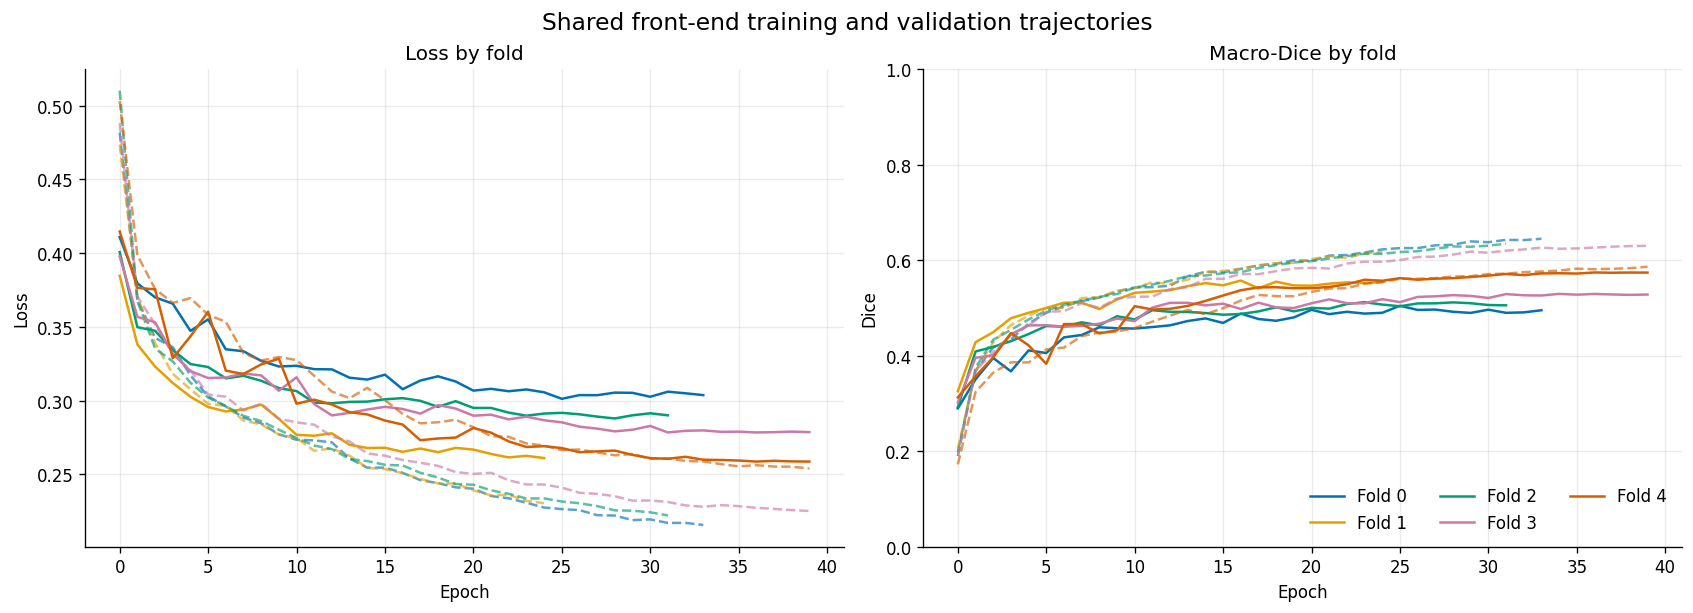

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for fold, color in zip(EXPECTED_FOLDS, FOLD_COLORS):
    fold_history = history[history["fold"] == fold]
    axes[0].plot(fold_history["epoch"], fold_history["train_loss"], color=color, ls="--", alpha=0.65)
    axes[0].plot(fold_history["epoch"], fold_history["validation_loss"], color=color, label=f"Fold {fold}")
    axes[1].plot(fold_history["epoch"], fold_history["train_macro_dice"], color=color, ls="--", alpha=0.65)
    axes[1].plot(fold_history["epoch"], fold_history["validation_macro_dice"], color=color, label=f"Fold {fold}")

axes[0].set(title="Loss by fold", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Macro-Dice by fold", xlabel="Epoch", ylabel="Dice", ylim=(0, 1))
axes[1].legend(ncol=3, frameon=False, loc="lower right")
fig.suptitle("Shared front-end training and validation trajectories", fontsize=14)
plt.show()

## Across-fold learning trend

The mean curve uses the folds available at each epoch; the shaded band is ±1 standard deviation. The number of contributing folds is reported below the plot so later epochs are not mistaken for five-fold estimates.

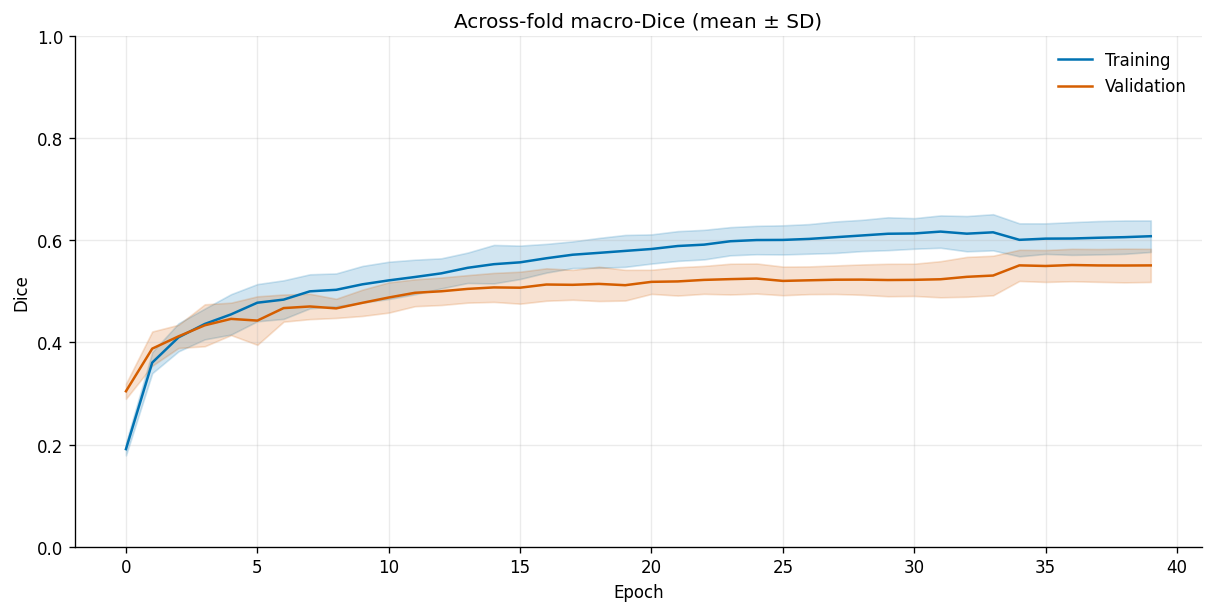

,folds
epoch,
0,5
25,4
32,3
34,2


In [4]:
epoch_summary = history.groupby("epoch").agg(
    folds=("fold", "nunique"),
    train_mean=("train_macro_dice", "mean"),
    train_std=("train_macro_dice", "std"),
    validation_mean=("validation_macro_dice", "mean"),
    validation_std=("validation_macro_dice", "std"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
for prefix, label, color in [
    ("train", "Training", "#0072B2"),
    ("validation", "Validation", "#D55E00"),
]:
    mean = epoch_summary[f"{prefix}_mean"]
    std = epoch_summary[f"{prefix}_std"].fillna(0)
    ax.plot(epoch_summary["epoch"], mean, color=color, label=label)
    ax.fill_between(epoch_summary["epoch"], mean - std, mean + std, color=color, alpha=0.18)

ax.set(
    title="Across-fold macro-Dice (mean ± SD)",
    xlabel="Epoch", ylabel="Dice", ylim=(0, 1),
)
ax.legend(frameon=False)
plt.show()

display(epoch_summary[["epoch", "folds"]].drop_duplicates("folds").set_index("epoch"))

## Best checkpoint summary

Each fold contributes the row at its maximum validation macro-Dice. The left panel compares overall validation performance; the right panel exposes bone-specific behavior at those selected epochs.

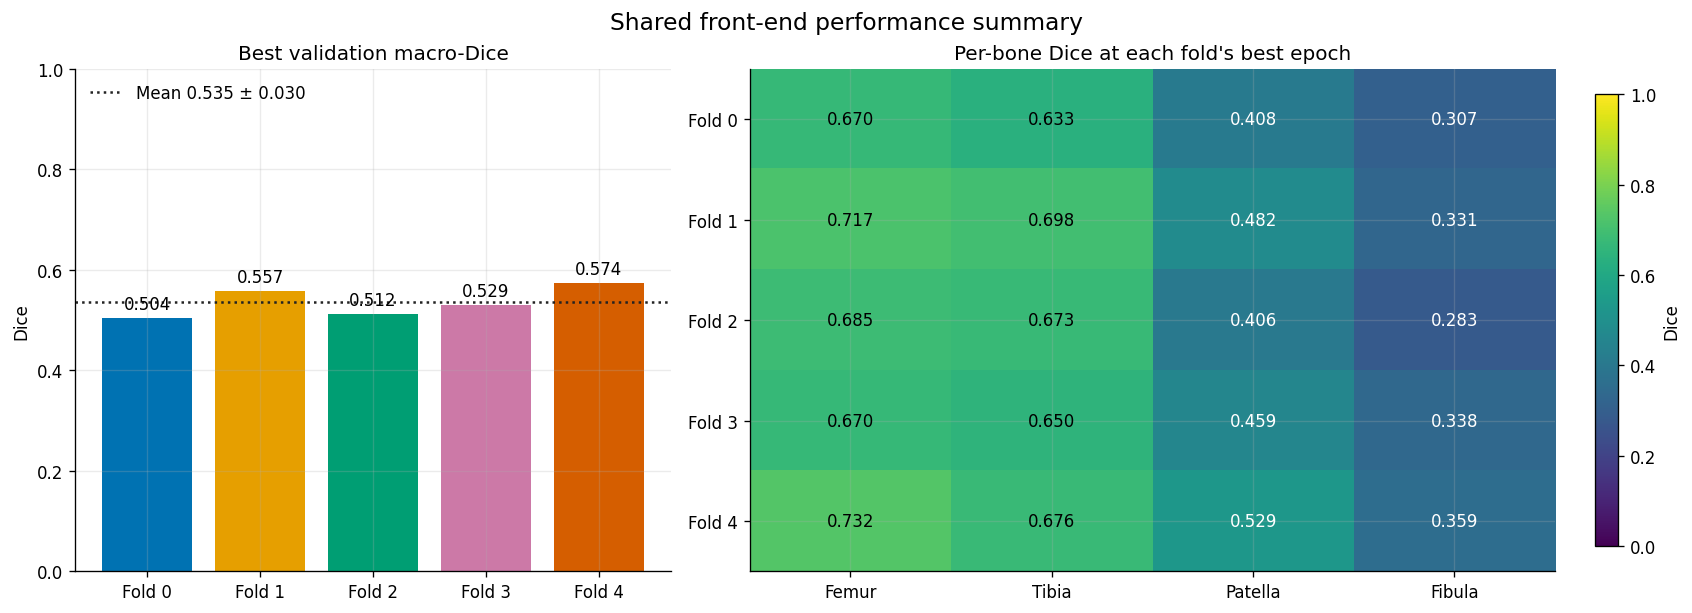

In [5]:
best_indices = history.groupby("fold")["validation_macro_dice"].idxmax()
best = history.loc[best_indices].sort_values("fold").reset_index(drop=True)
best["runtime_minutes"] = best["elapsed_seconds"] / 60
best["train_validation_gap"] = best["train_macro_dice"] - best["validation_macro_dice"]

bone_columns = [f"validation_dice_{bone}" for bone in BONES]
bone_matrix = best[bone_columns].to_numpy()
fold_labels = [f"Fold {fold}" for fold in best["fold"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1.35]}, constrained_layout=True)
bars = axes[0].bar(fold_labels, best["validation_macro_dice"], color=FOLD_COLORS)
mean_macro = best["validation_macro_dice"].mean()
std_macro = best["validation_macro_dice"].std()
axes[0].axhline(mean_macro, color="#222222", lw=1.5, ls=":", label=f"Mean {mean_macro:.3f} ± {std_macro:.3f}")
axes[0].bar_label(bars, fmt="%.3f", padding=3)
axes[0].set(title="Best validation macro-Dice", ylabel="Dice", ylim=(0, 1))
axes[0].legend(frameon=False, loc="upper left")

image = axes[1].imshow(bone_matrix, cmap="viridis", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(len(BONES)), [bone.title() for bone in BONES])
axes[1].set_yticks(range(len(fold_labels)), fold_labels)
axes[1].set_title("Per-bone Dice at each fold's best epoch")
for row in range(bone_matrix.shape[0]):
    for column in range(bone_matrix.shape[1]):
        value = bone_matrix[row, column]
        axes[1].text(column, row, f"{value:.3f}", ha="center", va="center", color="white" if value < 0.55 else "black")
fig.colorbar(image, ax=axes[1], label="Dice", shrink=0.9)
fig.suptitle("Shared front-end performance summary", fontsize=14)
plt.show()

## Fold-level and aggregate results

The aggregate row summarizes the five independently selected best checkpoints. Standard deviation uses the sample definition (`ddof=1`).

In [6]:
summary_columns = [
    "fold", "epoch", "validation_loss", "validation_macro_dice",
    *bone_columns, "train_validation_gap", "runtime_minutes",
]
fold_summary = best[summary_columns].rename(columns={
    "epoch": "best_epoch",
    "validation_loss": "val_loss",
    "validation_macro_dice": "val_macro_dice",
    **{f"validation_dice_{bone}": f"dice_{bone}" for bone in BONES},
})

numeric_columns = [column for column in fold_summary.columns if column != "fold"]
aggregate = pd.DataFrame({
    "mean": fold_summary[numeric_columns].mean(),
    "std": fold_summary[numeric_columns].std(),
}).T

display(fold_summary.round(4).set_index("fold"))
display(aggregate.round(4))

bone_summary = fold_summary[[f"dice_{bone}" for bone in BONES]].agg(["mean", "std"]).T
bone_summary.index = [bone.title() for bone in BONES]
display(bone_summary.round(4).rename(columns={"mean": "mean_dice", "std": "std_dice"}))

,best_epoch,val_loss,val_macro_dice,dice_femur,dice_tibia,dice_patella,dice_fibula,train_validation_gap,runtime_minutes
fold,,,,,,,,,
0,25,0.3012,0.5044,0.6699,0.6331,0.4077,0.3068,0.1208,17.2983
1,16,0.2652,0.5571,0.7169,0.6983,0.4821,0.3311,0.0248,11.5217
2,23,0.2897,0.5118,0.6854,0.6735,0.4056,0.2827,0.1014,15.9433
3,34,0.2788,0.5292,0.6704,0.6500,0.4585,0.3381,0.0945,23.0533
4,36,0.2586,0.5740,0.7323,0.6758,0.5290,0.3589,0.0068,24.6533


,best_epoch,val_loss,val_macro_dice,dice_femur,dice_tibia,dice_patella,dice_fibula,train_validation_gap,runtime_minutes
mean,26.800,0.2787,0.5353,0.6950,0.6661,0.4566,0.3235,0.0696,18.4940
std,8.228,0.0174,0.0297,0.0283,0.0252,0.0522,0.0294,0.0505,5.3683


,mean_dice,std_dice
Femur,0.6950,0.0283
Tibia,0.6661,0.0252
Patella,0.4566,0.0522
Fibula,0.3235,0.0294


## Interpretation guardrails

- These curves measure the disposable supervision heads used to train the shared front end; they are not U-Base or V-Base reconstruction results.
- Selecting each fold's best validation epoch is appropriate for checkpoint reporting, but it is not an unbiased estimate of held-out test performance.
- Per-bone Dice highlights whether smaller structures (especially patella and fibula) lag behind femur and tibia before the shared front end is frozen for decoder comparison.
- Full decoder cross-validation remains dependent on the Stage 2 independent QA gate.